In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

import sys
    
    
sys.path.insert(0, '/cosma/home/dp004/dc-zhan5')
import MyHaloPS as ps
import importlib
importlib.reload(ps)
import pickle


In [2]:
import seaborn as sns
palette_tab10 = sns.color_palette("colorblind", 10)
color_list1 = palette_tab10[1:2] + ["gold"]
color_list2 = palette_tab10[0:1]  + palette_tab10[9:10]

In [7]:
odir = "ps_data"
with open(f"{odir}/dm/TNG300-3-Dark/snap0/test1.pickle", "rb") as f:
    Pk0 = pickle.load(f)
    
print("shotnoise", Pk0.attrs["shotnoise"])

shotnoise 0.035287552


In [147]:
odir = "ps_data"
with open(f"{odir}/dm/TNG300-3-Dark/snap0/Nmesh2448.pickle", "rb") as f:
    Pk0 = pickle.load(f)
    
print("shotnoise", Pk0.attrs["shotnoise"])

shotnoise 0.035287552


In [36]:
odir = "ps_data"
with open(f"{odir}/dm/TNG300-3-Dark/snap40/test4.pickle", "rb") as f:
    Pk40 = pickle.load(f)
    
print("shotnoise", Pk40.attrs["shotnoise"])

shotnoise 0.035287552


In [47]:
#odir = "../ps_data"
with open(f"{odir}/snap40/mvir/ps-intensity-sum_logM10.pickle", "rb") as f:
    Pk_mean_gal10 = pickle.load(f)
    Pk_sum10 = pickle.load(f)

In [117]:
#odir = "../ps_data"
with open(f"{odir}/snap40/mvir/ps-intensity-gal_logM10.pickle", "rb") as f:
    Pk_mean_gal10 = pickle.load(f)
    Pk_gal10 = pickle.load(f)

In [37]:
from colossus.cosmology import cosmology
cosmo = cosmology.setCosmology('planck15')

In [81]:
z = 1.5
D15 = cosmo.growthFactorUnnormalized(z)
D127 = cosmo.growthFactorUnnormalized(127)
growth_factor15 = (D15/D127)**2
print(growth_factor)

35.639600113129454


In [82]:
cosmo = cosmology.setCosmology('planck15')
z = 20
D20 = cosmo.growthFactorUnnormalized(z)
D127 = cosmo.growthFactorUnnormalized(127)
growth_factor20 = (D20/D127)**2
print(growth_factor)

35.639600113129454


In [83]:
growth_factor = (D15/D20)**2


In [58]:
from nbodykit.lab import cosmology as n_cosmology
c      = n_cosmology.Planck15
c = c.clone(P_k_max=100)
#c = n_cosmology.Cosmology(h=0.67556, T0_cmb=2.7255, Omega0_b=0.0482754208891869, Omega0_cdm=0.26377065934278865, N_ur=None, m_ncdm=[0.06], P_k_max=100.0, P_z_max=100.0, gauge='synchronous', n_s=0.9667, nonlinear=False, verbose=False)
#Plin   = n_cosmology.LinearPower(c, redshift=1.5, transfer='CLASS')
Plin15   = n_cosmology.LinearPower(c, redshift=1.5, transfer='CLASS')

Pnl15 = n_cosmology.power.halofit.HalofitPower(c, redshift=1.5) 

In [40]:
ks = Pk40['k']
logks = np.log10(Pk40['k'])

In [41]:
Pk_lin_colossus_15 = cosmo.matterPowerSpectrum(ks, 1.5)
Pk_lin_colossus_20 = cosmo.matterPowerSpectrum(ks, 20)
Pk_lin_colossus_ic = cosmo.matterPowerSpectrum(ks, 127)

In [56]:
(205**3)*1/625**3

0.035287552

In [156]:
iend = 191

### Redshift 20

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:2: RuntimeWarning: invalid value encountered in log10
  


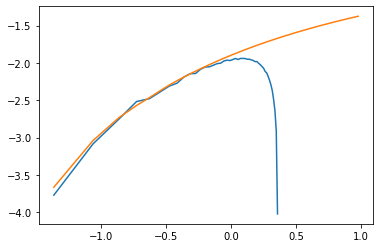

In [157]:
kcoef = (ks**3)/(2*np.pi**2)
plt.plot(logks, np.log10(kcoef*(Pk0["power"].real[:iend]-Pk0.attrs["shotnoise"])))
plt.plot(logks, np.log10(kcoef*Pk_lin_colossus_20[:iend]))


Text(0.5, 0, '$\\rm log_{10}(k [h Mpc{-1}])$')

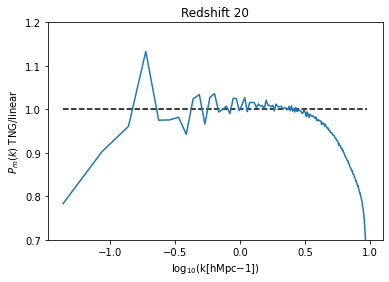

In [164]:
plt.plot(logks, [1]*len(ks), linestyle="dashed", c="k")
plt.plot(logks, (Pk0["power"].real[:iend])/Pk_lin_colossus_20[:iend])
plt.ylim(0.7,1.2)
plt.title("Redshift 20")
plt.ylabel("$P_m(k)$ TNG/linear")
plt.xlabel(r"$\rm log_{10}(k [h Mpc{-1}])$")

## z = 1.5

### Using redshift 20 as shape of linear power spectrum

In [85]:
predicted15 = Pk0["power"].real * growth_factor

Text(0.5, 0, '$\\rm log_{10}(k [h Mpc{-1}])$')

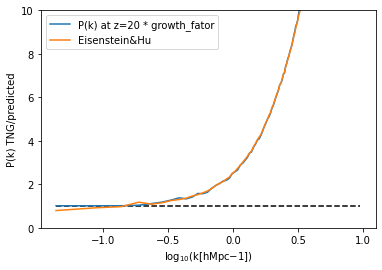

In [166]:
plt.plot(logks, [1]*len(ks), linestyle="dashed", c="k")

plt.plot(logks, (Pk40["power"].real-Pk40.attrs["shotnoise"])/(predicted15), label="P(k) at z=20 * growth_fator")
plt.plot(logks, (Pk40["power"].real-Pk40.attrs["shotnoise"])/(Pk_lin_colossus_15), label="Eisenstein&Hu")
plt.ylabel("P(k) TNG/predicted")
plt.ylim(0,10)
plt.legend()
plt.xlabel(r"$\rm log_{10}(k [h Mpc{-1}])$")

### Halo power spectrum

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:2: RuntimeWarning: invalid value encountered in log10
  


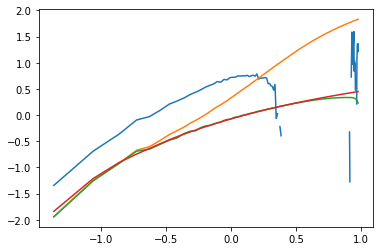

In [165]:
kcoef = (ks**3)/(2*np.pi**2)
plt.plot(logks, np.log10(kcoef*(Pk_sum10["power"].real[:191]-Pk_sum10.attrs["shotnoise"])))
plt.plot(logks, np.log10(kcoef*(Pk40["power"].real-Pk40.attrs["shotnoise"])))
plt.plot(logks, np.log10(kcoef*(predicted15)))

plt.plot(logks, np.log10(kcoef*Pk_lin_colossus_15))


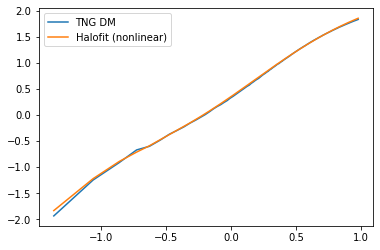

In [62]:
plt.plot(logks, np.log10(kcoef*(Pk40["power"].real-Pk40.attrs["shotnoise"])), label="TNG DM")
plt.plot(logks, np.log10(kcoef*Pnl15(ks)), label="Halofit (nonlinear)")
plt.legend()

Text(0.5, 0, '$\\rm log_{10}(k [h Mpc{-1}])$')

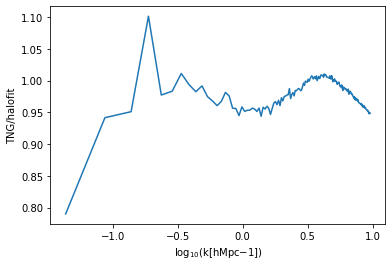

In [106]:
plt.plot(logks, (Pk40["power"].real-Pk40.attrs["shotnoise"])/Pnl15(ks), label="TNG DM")
plt.ylabel("TNG/halofit")
plt.xlabel(r"$\rm log_{10}(k [h Mpc{-1}])$")

Text(0.5, 0, '$\\rm log_{10}(k [h Mpc{-1}])$')

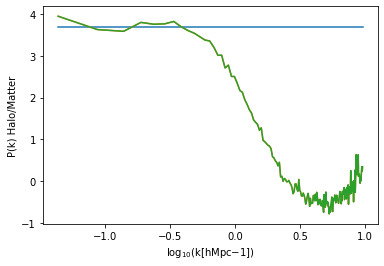

In [140]:
plt.plot(logks, [3.7]*len(ks))
ratio15 = (Pk_sum10["power"].real[:191]-Pk_sum10.attrs["shotnoise"])/(Pk40["power"].real-Pk40.attrs["shotnoise"])
plt.plot(logks, ratio15)
#ratio15 = (Pk_sum10["power"].real[:191])/(Pk40["power"].real-Pk40.attrs["shotnoise"])

plt.plot(logks, ratio15)
plt.ylabel("P(k) Halo/Matter")
plt.xlabel(r"$\rm log_{10}(k [h Mpc{-1}])$")


(0.0, 20.0)

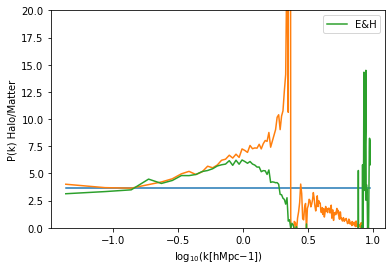

In [162]:
plt.plot(logks, [3.7]*len(ks))
ratio15 = (Pk_sum10["power"].real[:191]-Pk_sum10.attrs["shotnoise"])/(growth_factor*(Pk0["power"].real[:iend]-Pk0.attrs["shotnoise"]))
plt.plot(logks, ratio15)
ratio15 = (Pk_sum10["power"].real[:191]-Pk_sum10.attrs["shotnoise"])/(Pk_lin_colossus_15)
plt.plot(logks, ratio15, label="E&H")

#ratio15 = (Pk_sum10["power"].real[:191])/(Pk40["power"].real-Pk40.attrs["shotnoise"])

#plt.plot(logks, ratio15)
plt.legend()
plt.ylabel("P(k) Halo/Matter")
plt.xlabel(r"$\rm log_{10}(k [h Mpc{-1}])$")
plt.ylim(0,20)

In [115]:
print(logks[:10])
print(ratio15[:10])
print(np.mean(ratio15[:10]))

[-1.36238139 -1.06033518 -0.85899558 -0.7254722  -0.62661141 -0.54272913
 -0.473019   -0.41424164 -0.3611729  -0.3135468 ]
[3.9471112  3.62821376 3.58608166 3.79942528 3.75508923 3.76500327
 3.82222791 3.69085305 3.60144025 3.53789545]
3.7133341047398716


Text(0.5, 0, '$\\rm log_{10}(k [h Mpc{-1}])$')

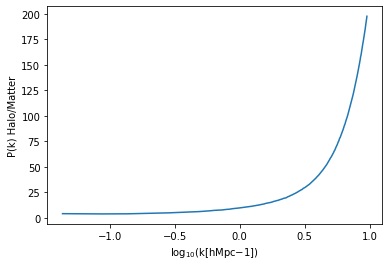

In [110]:
plt.plot(logks, (Pk_sum10["power"].real[:191])/(Pk40["power"].real-Pk40.attrs["shotnoise"]))
plt.ylabel("P(k) Halo/Matter")
plt.xlabel(r"$\rm log_{10}(k [h Mpc{-1}])$")


In [ ]:
plt.plot(logks, (Pk_sum10["power"].real[:191]-Pk_sum10.attrs["shotnoise"])/(Pk40["power"].real-Pk40.attrs["shotnoise"]))


### Galaxy power spectrum

In [130]:
iend =191

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/core/_asarray.py:83: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)


Text(0.5, 0, '$\\rm log_{10}(k [h Mpc{-1}])$')

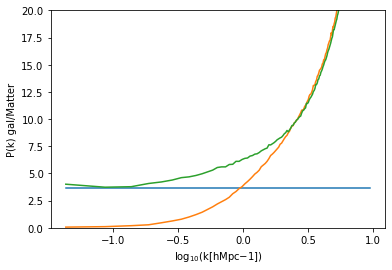

In [138]:
plt.plot(logks, [3.7]*len(ks))
ratio15 = (Pk_gal10["power"].real[:iend]-Pk_gal10.attrs["shotnoise"])/(Pk40["power"].real-Pk40.attrs["shotnoise"])
plt.plot(np.log10(Pk_gal10["k"][:iend]), (Pk_gal10["power"][:iend]-(Pk_sum10["power"][:iend]-Pk_sum10.attrs["shotnoise"])- Pk_gal10.attrs["shotnoise"])/(Pk40["power"].real-Pk40.attrs["shotnoise"]))

plt.plot(logks, ratio15)
plt.ylim(0,20)
plt.ylabel("P(k) gal/Matter")
plt.xlabel(r"$\rm log_{10}(k [h Mpc{-1}])$")
